In [1]:
import numpy as np
import pandas as pd

In [2]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [3]:
from data_science.plots import plot_clusters, plot_dendrogram, plot_pca_scatter


## Data


In [4]:
data = pd.read_csv(
    './../../data/wine_quality_merged.csv',
)

## Prepare Data


In [5]:
RANDOM_STATE = 42
np.random.default_rng(RANDOM_STATE)

Generator(PCG64) at 0x11E00F680

In [6]:
X = data.drop(columns=['type'])
y = data['type']

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

## PCA


In [9]:
pca_2d = PCA(
    n_components=2,
    random_state=RANDOM_STATE,
)
X_pca_2d = pca_2d.fit_transform(X_scaled)

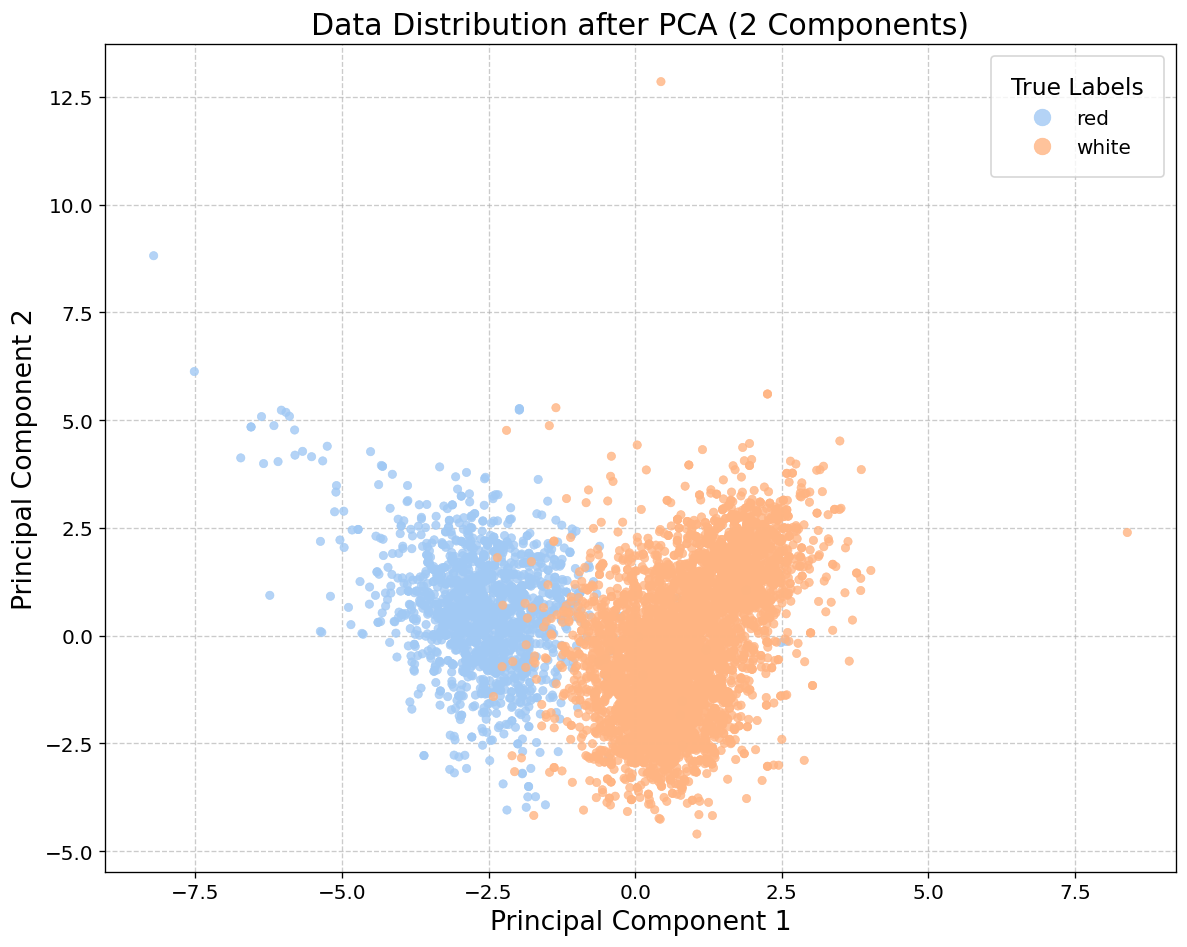

In [10]:
plot_pca_scatter(
    X_pca_2d,
    y,
    title='Data Distribution after PCA (2 Components)',
    palette='pastel',
)

## Agglomerative Clustering


### Ward Linkage


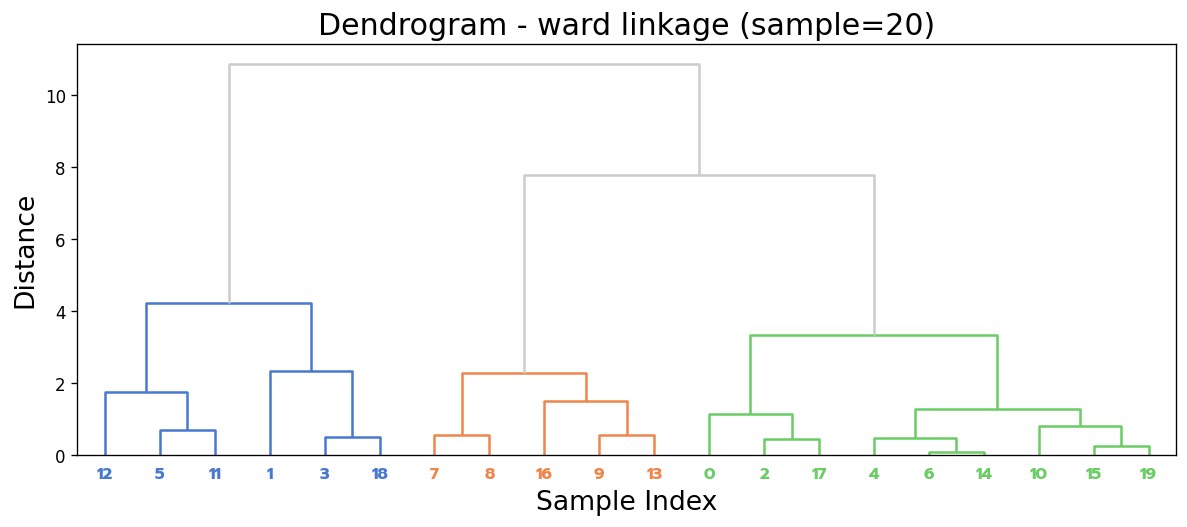

In [11]:
plot_dendrogram(X_pca_2d, p=2, method='ward', size=20)

In [12]:
agg_ward = AgglomerativeClustering(
    n_clusters=2,
    metric='euclidean',
    linkage='ward',
)
agg_ward.fit(X_pca_2d)

,n_clusters,2
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


(6497,)
(6497, 2)


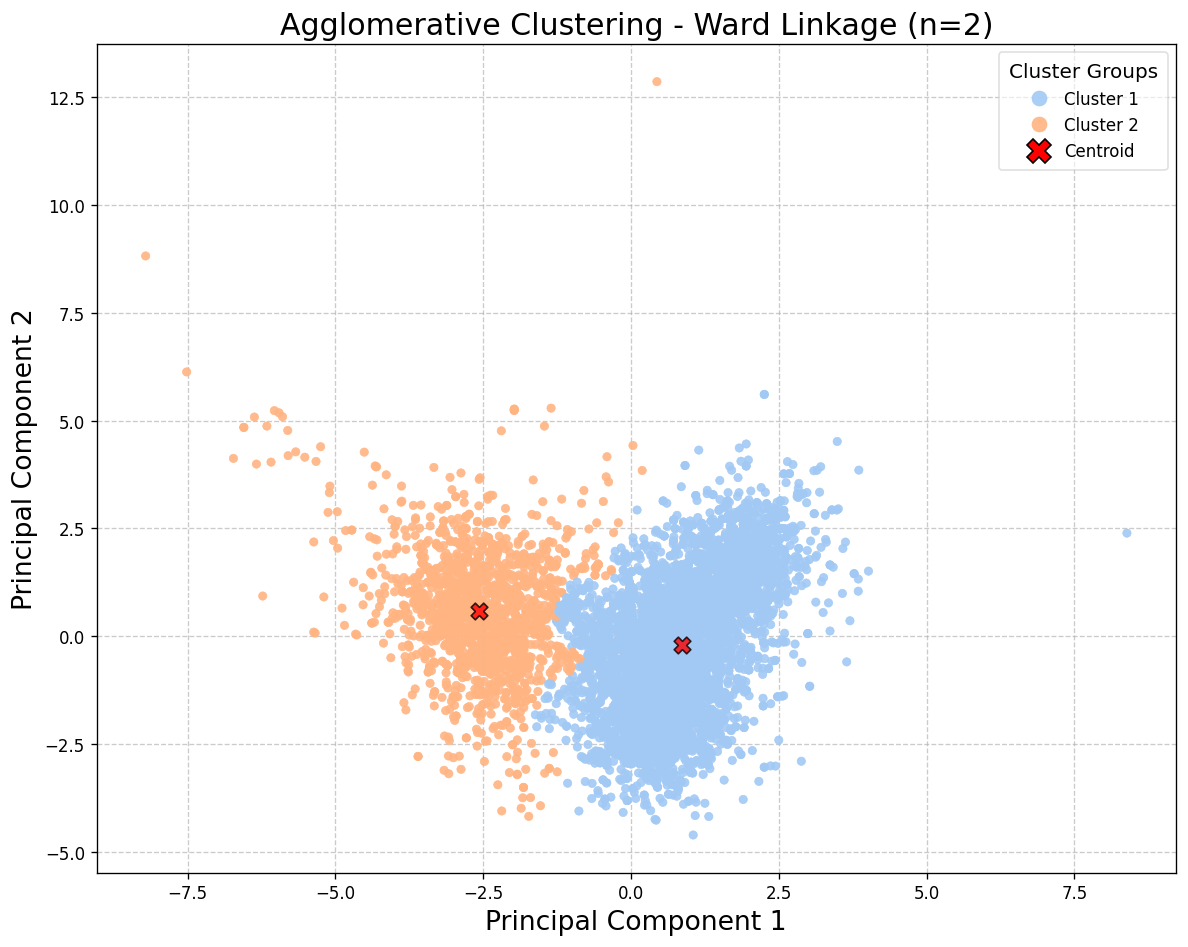

In [13]:
print(agg_ward.labels_.shape)
print(X_pca_2d.shape)
plot_clusters(
    agg_ward.labels_,
    X_pca_2d,
    title='Agglomerative Clustering - Ward Linkage (n=2)',
    palette='pastel',
)

### Complete Linkage


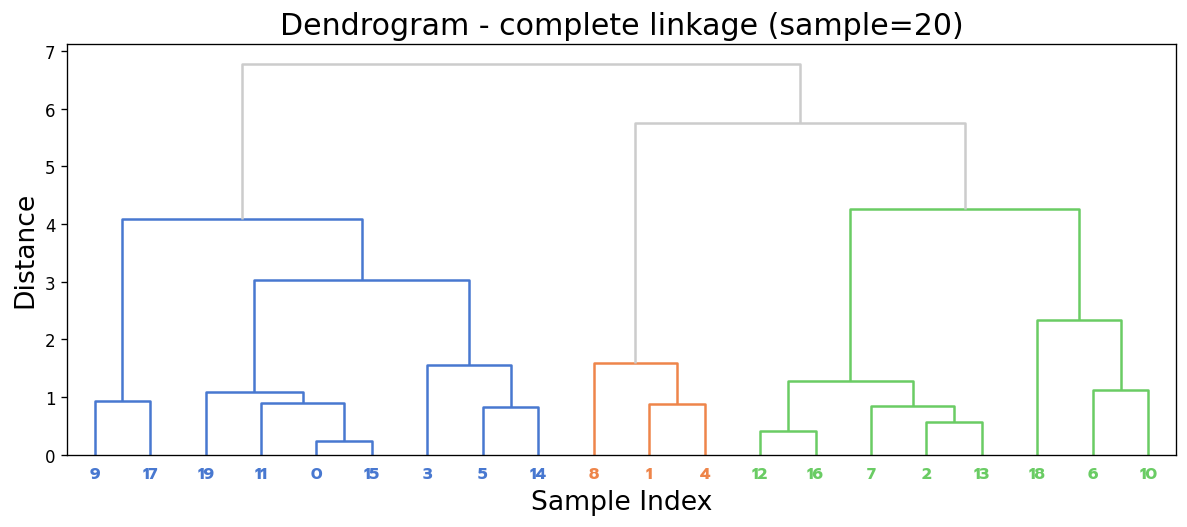

In [14]:
plot_dendrogram(X_pca_2d, p=2, method='complete', size=20)

In [15]:
agg_complete = AgglomerativeClustering(
    n_clusters=2,
    metric='euclidean',
    linkage='complete',
)
agg_complete.fit(X_pca_2d)

,n_clusters,2
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'complete'
,distance_threshold,None
,compute_distances,False


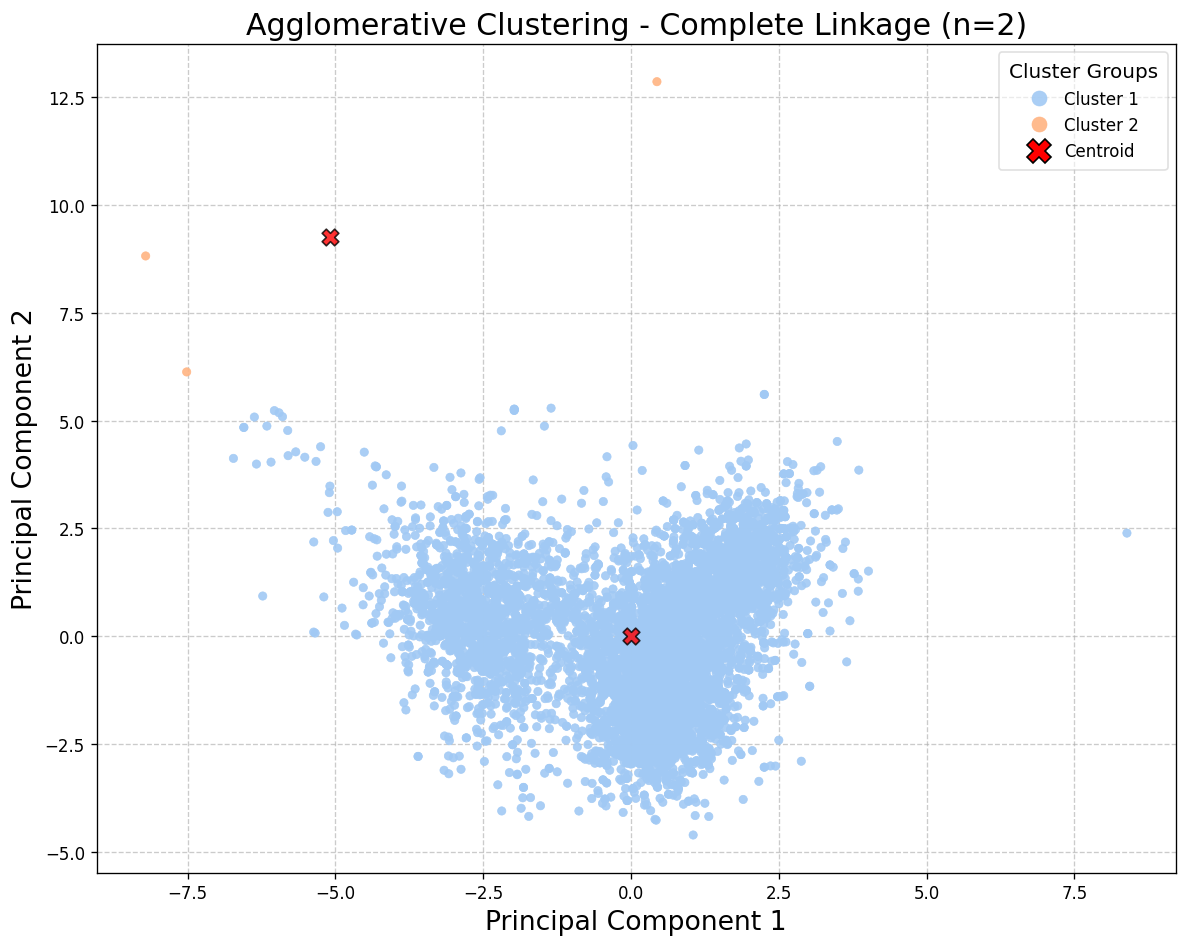

In [16]:
plot_clusters(
    agg_complete.labels_,
    X_pca_2d,
    title='Agglomerative Clustering - Complete Linkage (n=2)',
    palette='pastel',
)

### Average Linkage


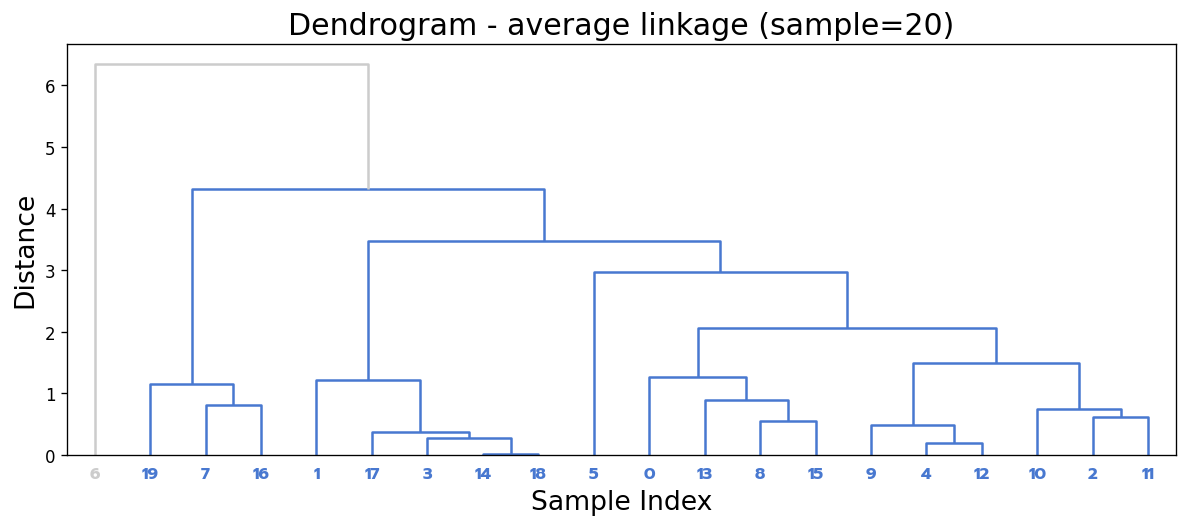

In [17]:
plot_dendrogram(X_pca_2d, p=10, method='average', size=20)

In [18]:
agg_average = AgglomerativeClustering(
    n_clusters=2,
    metric='euclidean',
    linkage='average',
)
agg_average.fit(X_pca_2d)

,n_clusters,2
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'average'
,distance_threshold,None
,compute_distances,False


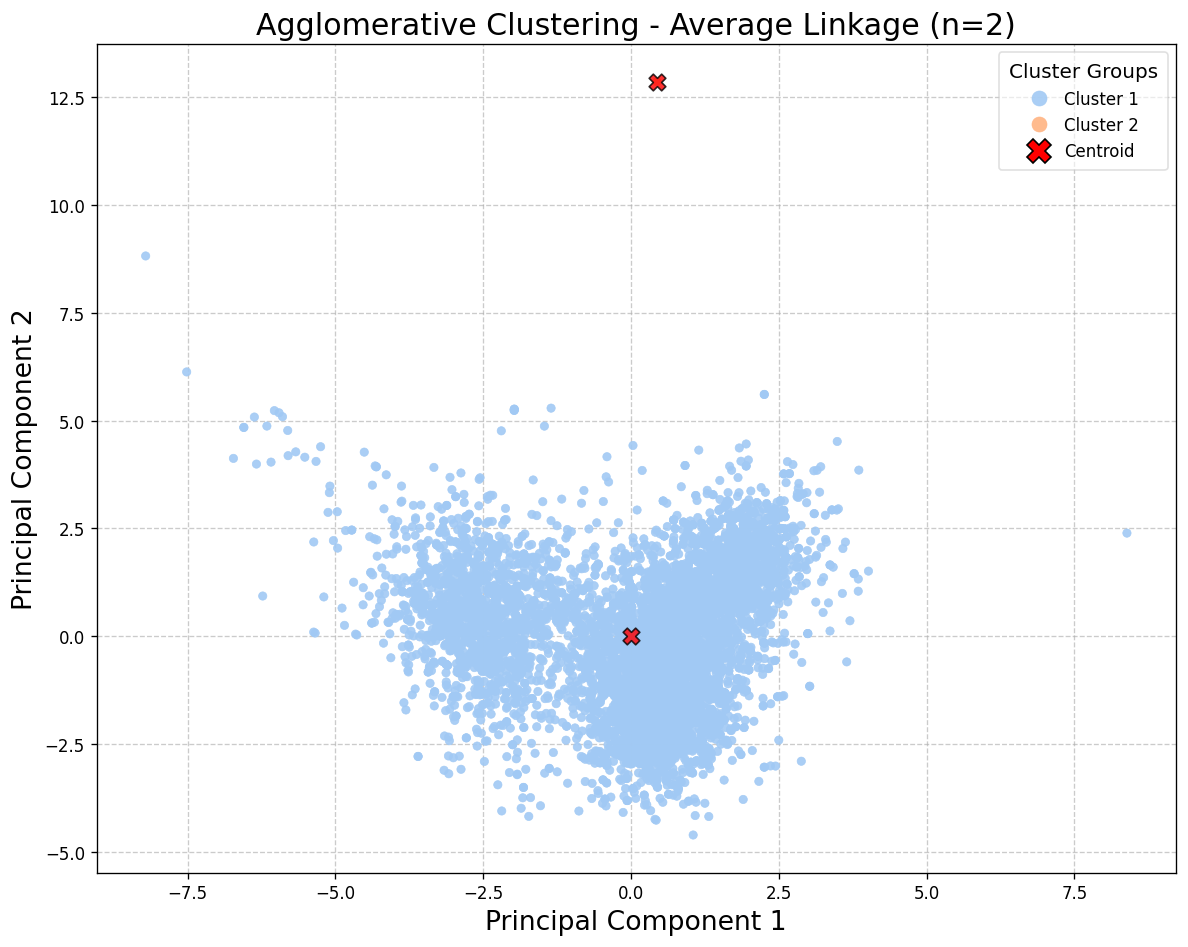

In [19]:
plot_clusters(
    agg_average.labels_,
    X_pca_2d,
    title='Agglomerative Clustering - Average Linkage (n=2)',
    palette='pastel',
)

### Single Linkage


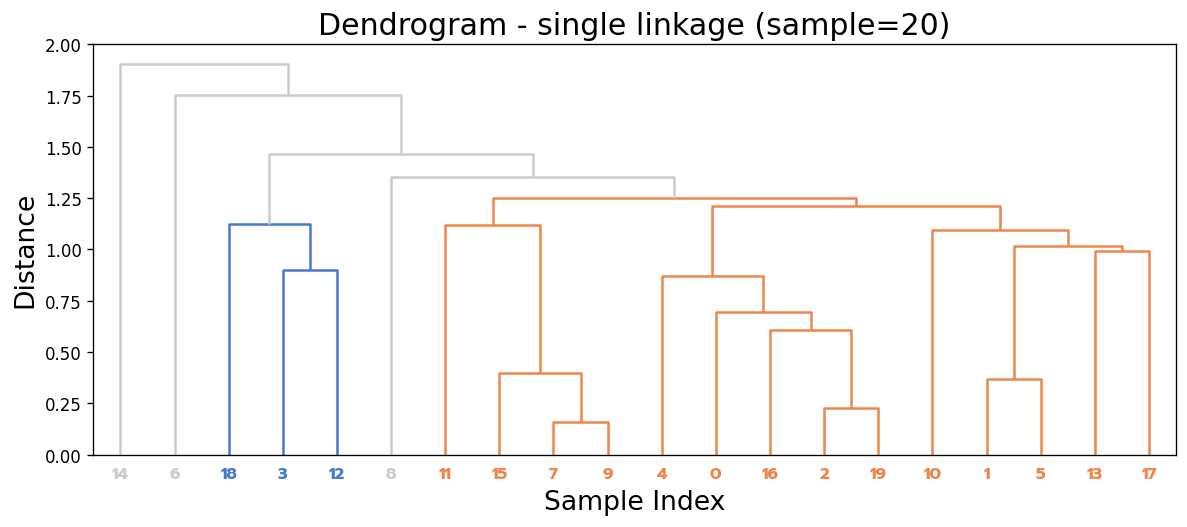

In [20]:
plot_dendrogram(X_pca_2d, p=10, method='single', size=20)

In [21]:
agg_single = AgglomerativeClustering(
    n_clusters=2,
    metric='euclidean',
    linkage='single',
)
agg_single.fit(X_pca_2d)

,n_clusters,2
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'single'
,distance_threshold,None
,compute_distances,False


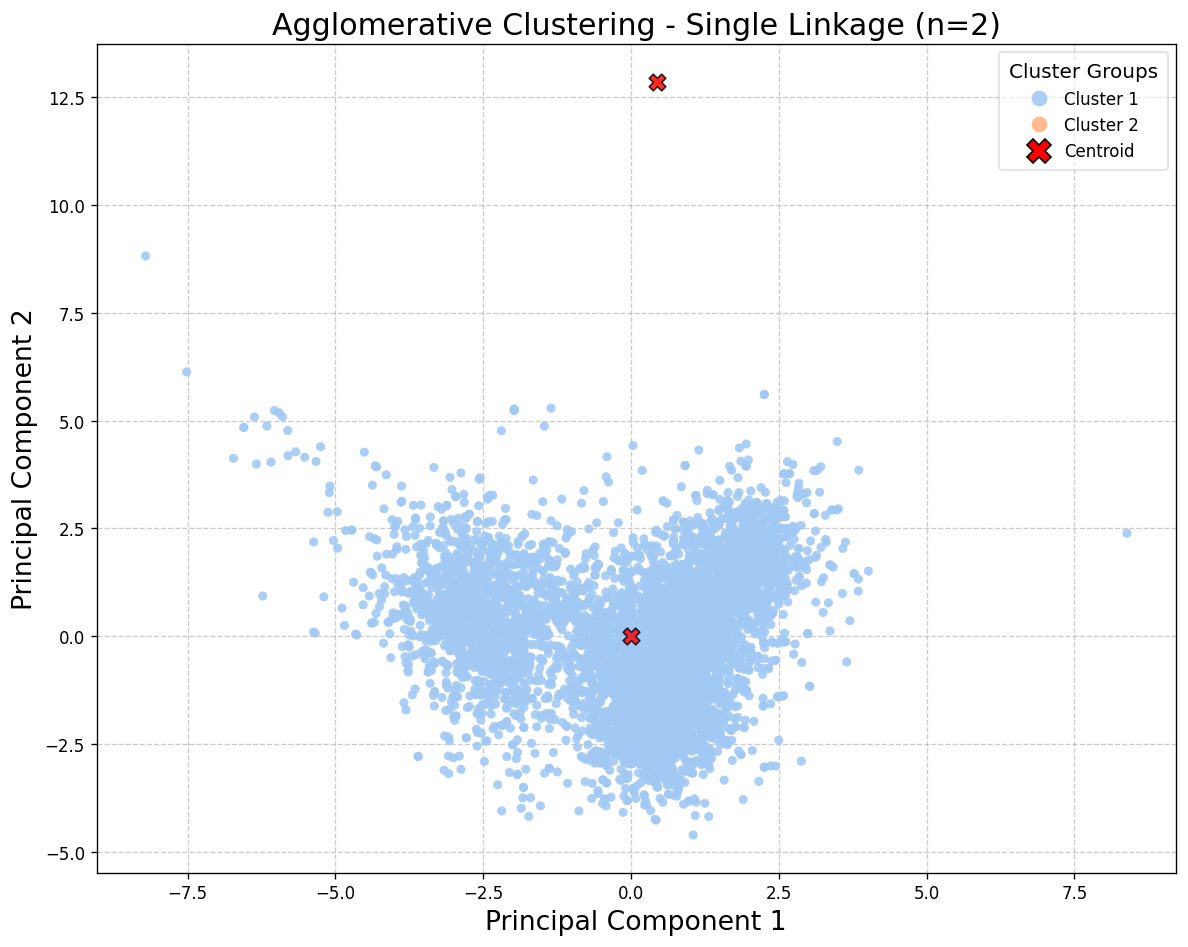

In [22]:
plot_clusters(
    agg_single.labels_,
    X_pca_2d,
    title='Agglomerative Clustering - Single Linkage (n=2)',
    palette='pastel',
)

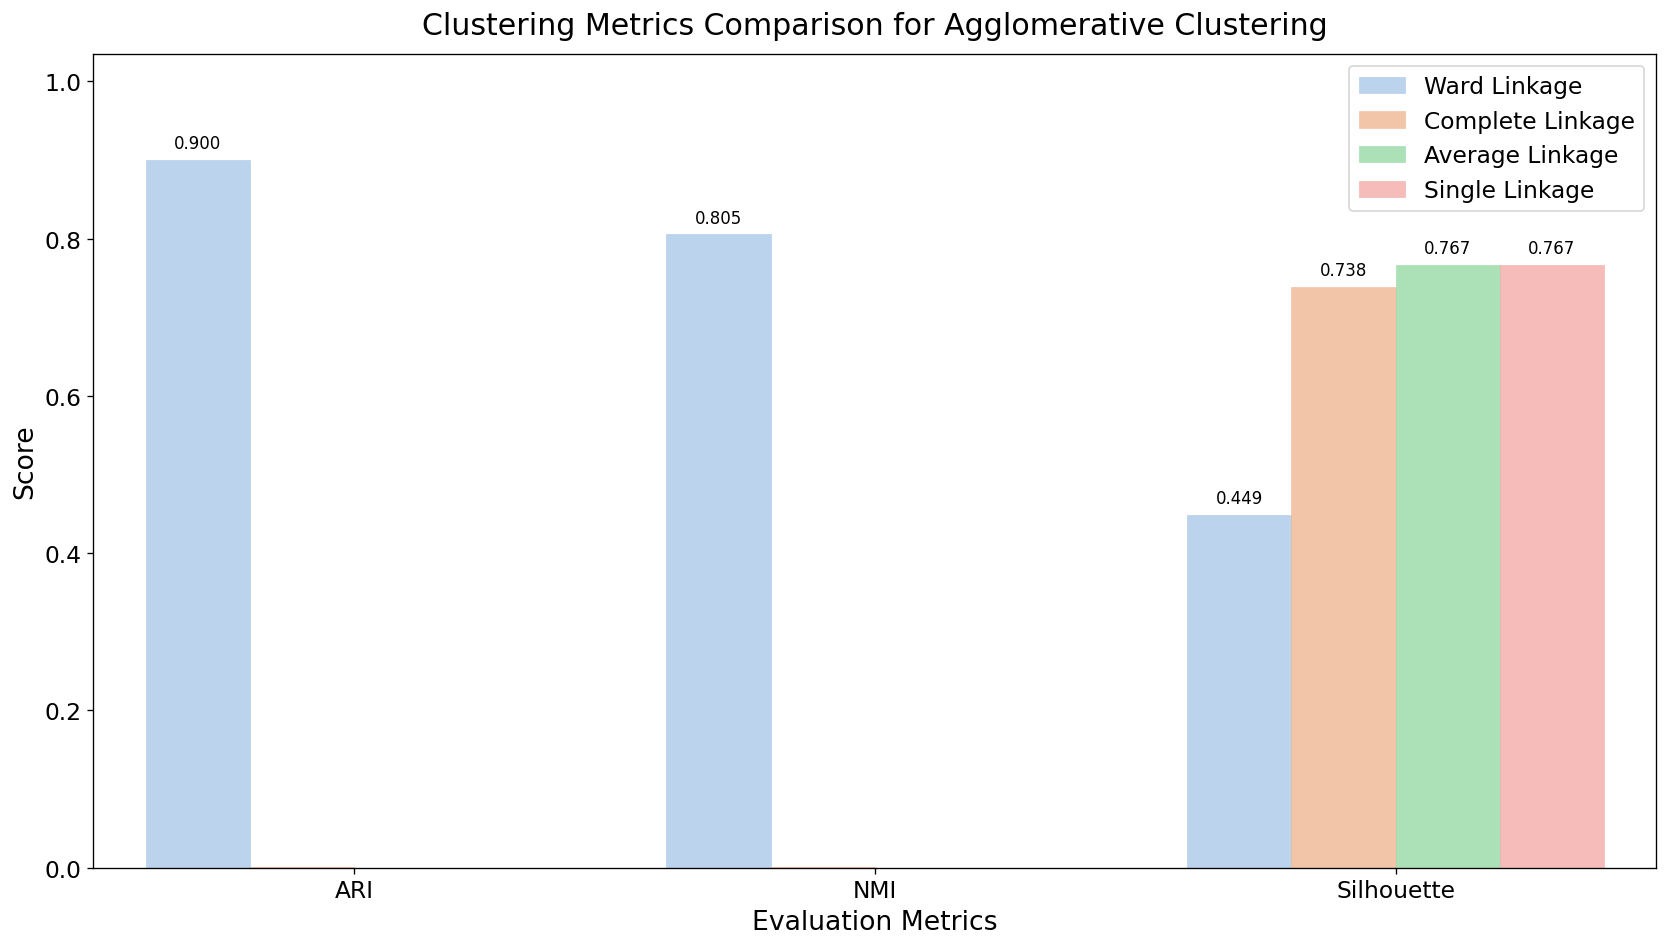

In [ ]:
from data_science.tests import evaluate_clustering_performance, plot_clustering_metrics

_ = plot_clustering_metrics(
    results=[
        ('Ward Linkage', evaluate_clustering_performance(y, agg_ward.labels_, X_pca_2d)),
        ('Complete Linkage', evaluate_clustering_performance(y, agg_complete.labels_, X_pca_2d)),
        ('Average Linkage', evaluate_clustering_performance(y, agg_average.labels_, X_pca_2d)),
        ('Single Linkage', evaluate_clustering_performance(y, agg_single.labels_, X_pca_2d)),
    ],
    title='Clustering Metrics Comparison for Agglomerative Clustering',
    palette='pastel',
    metrics=[
        "adjusted_rand_score",
        "normalized_mutual_info",
        "silhouette"
    ]
)
